# ACV Refrigerant-Leak Localization

**Task** (from `data/ACV/ACV/ACV_Subsystem_Info_Kit.md`): for each case file, rank all
8 cars from most- to least-likely to have the refrigerant leak. Scored per file as
`score = (n - (r - 1)) / n`, where `r` is the rank (1 = most likely) given to the true
faulty car and `n` is the number of cars ranked -- the organizers' exact formula,
reproduced below, not an approximation.

Everything in this notebook is plain pandas in the cells themselves -- no separate
module to import and get out of sync with.

## 1. Load the data and check the schema directly

Before assuming anything about column names, load every training file and the test
file and print their actual headers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRAIN_DIR = Path("data/ACV/ACV/Train")
TEST_DIR = Path("data/ACV/ACV/Test")
LABELS_PATH = Path("data/ACV/ACV/Train_Labels.csv")

train_paths = sorted(TRAIN_DIR.glob("*.xlsx"))
test_paths = sorted(TEST_DIR.glob("*.xlsx"))
labels = pd.read_csv(LABELS_PATH, dtype=str).set_index("filename")["faulty_car"]
labels

filename
acv_case_01.xlsx    01
acv_case_02.xlsx    02
acv_case_03.xlsx    03
acv_case_04.xlsx    01
acv_case_05.xlsx    04
acv_case_06.xlsx    06
Name: faulty_car, dtype: str

In [2]:
for path in train_paths + test_paths:
    df = pd.read_excel(path, engine="openpyxl", nrows=1)
    print(f"{path.name}: {len(df.columns)} columns")

acv_case_01.xlsx: 67 columns
acv_case_02.xlsx: 67 columns
acv_case_03.xlsx: 67 columns
acv_case_04.xlsx: 483 columns
acv_case_05.xlsx: 67 columns
acv_case_06.xlsx: 67 columns
acv_test_case.xlsx: 67 columns


**What this shows.** `acv_case_04.xlsx` has 483 columns; every other training file and
the test file have 67. So the test file matches the *common* schema, not the outlier --
confirmed by checking, not assumed.

In [3]:
def car_ids_of(df: pd.DataFrame) -> list[str]:
    # "Car 01 - <parameter>" columns only -- excludes the "Car model" metadata
    # column, which also starts with "Car " but has no " - <parameter>" part.
    ids = set()
    for c in df.columns:
        if c.startswith("Car ") and " - " in c:
            number = c.split(" - ")[0][4:]
            if number.isdigit():
                ids.add(number)
    return sorted(ids)


sample = pd.read_excel(train_paths[0], engine="openpyxl", nrows=1)
params = [c.split(" - ", 1)[1] for c in sample.columns if c.startswith("Car 01 - ")]
print("Cars:", car_ids_of(sample))
print("Parameters per car:", params)

Cars: ['01', '02', '03', '04', '05', '06', '07', '08']
Parameters per car: ['ACV Control Temperature (Cooling)', 'ACV Control Temperature (Heating)', 'Load Halved', 'Indoor Average Temperature', 'Outdoor Average Temperature', 'ACV Setting Mode', 'ACV Information Valid', 'ACV Running Mode']


## 2. `acv_case_04.xlsx`'s schema genuinely doesn't match

Its columns use entirely different names (e.g. `Passenger Cabin Temperature Detected
Value` and `Target Temperature Value` instead of `Indoor Average Temperature` and
`ACV Control Temperature (Cooling)`), so the feature below can't be computed from it.
The test file doesn't have this problem (confirmed above), so there is nothing to fix
for the actual deliverable -- we simply exclude this one training file rather than
writing general schema-bridging logic for it.

In [4]:
EVAL_FILES = [p for p in train_paths if p.name != "acv_case_04.xlsx"]
print("Training files used below:", [p.name for p in EVAL_FILES])

Training files used below: ['acv_case_01.xlsx', 'acv_case_02.xlsx', 'acv_case_03.xlsx', 'acv_case_05.xlsx', 'acv_case_06.xlsx']


## 3. Data cleaning

Three checks, done once, kept simple:

- **Timestamps**: parse `Time` and sort by it -- cheap hygiene, doesn't change any
  mean we compute below, but keeps rows in a sane order.
- **Duplicate columns**: assert there are none (checked below -- there aren't).
- **Rows the file itself flags as bad**: `ACV Information Valid` is explicitly
  `"Invalid"` for a small number of rows per car. Those readings are untrustworthy by
  the file's own account, so they're excluded before computing anything -- not
  imputed, not guessed at, just left out.

In [5]:
def load_case(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path, engine="openpyxl")
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df = df.sort_values("Time").reset_index(drop=True)
    assert not df.columns.duplicated().any(), f"{path.name} has duplicate columns"
    return df


for path in EVAL_FILES + test_paths:
    df = load_case(path)
    invalid = sum((df[f"Car {car} - ACV Information Valid"] == "Invalid").sum() for car in car_ids_of(df))
    print(f"{path.name}: {len(df)} rows, {invalid} rows flagged Invalid across all cars")

acv_case_01.xlsx: 6999 rows, 25 rows flagged Invalid across all cars


acv_case_02.xlsx: 9187 rows, 44 rows flagged Invalid across all cars


acv_case_03.xlsx: 8310 rows, 1 rows flagged Invalid across all cars


acv_case_05.xlsx: 6972 rows, 0 rows flagged Invalid across all cars


acv_case_06.xlsx: 3263 rows, 0 rows flagged Invalid across all cars


acv_test_case.xlsx: 9082 rows, 25 rows flagged Invalid across all cars


## 4. One feature: how far above its own cooling setpoint does a car run?

A refrigerant leak reduces an AC unit's cooling capacity, so a leaking car should sit
further above its own cooling setpoint than a healthy peer while both are actively
trying to cool -- a well-documented undercharge signature. That's the one feature used
below: `mean(Indoor Average Temperature - ACV Control Temperature (Cooling))`, restricted
to timestamps where `ACV Running Mode` is `"Automatic Cooling"` or `"Full Cooling"` and
`ACV Information Valid` isn't `"Invalid"`.

In [6]:
ACTIVE_MODES = {"Automatic Cooling", "Full Cooling"}

def cooling_gap(df: pd.DataFrame, car: str) -> float:
    mode = df[f"Car {car} - ACV Running Mode"]
    valid = df[f"Car {car} - ACV Information Valid"] != "Invalid"
    active = mode.isin(ACTIVE_MODES) & valid
    actual = pd.to_numeric(df[f"Car {car} - Indoor Average Temperature"], errors="coerce")
    target = pd.to_numeric(df[f"Car {car} - ACV Control Temperature (Cooling)"], errors="coerce")
    return (actual - target)[active].mean()

## 5. Peer z-score ranking -- a heuristic, nothing is trained

For each file, convert every car's `cooling_gap` into a z-score against the other cars
in that same file only (median/MAD, robust to one extreme car), then rank cars by that
z-score. Comparing within-file avoids absolute-temperature effects like weather or
schedule that differ between files.

In [7]:
def peer_zscore(values: pd.Series) -> pd.Series:
    median = values.median()
    mad = (values - median).abs().median()
    scale = mad if mad > 0 else (values.std() if values.std() > 0 else 1.0)
    return (values - median) / scale


def rank_cars(df: pd.DataFrame) -> pd.Series:
    gaps = pd.Series({car: cooling_gap(df, car) for car in car_ids_of(df)})
    z = peer_zscore(gaps)
    return z.sort_values(ascending=False)

## 6. Score the baseline with the organizers' rank-decay formula

`score = (n - (r - 1)) / n`, applied exactly as specified, per training file.

In [8]:
def rank_decay_score(ranked_car_ids: list[str], true_car: str) -> float:
    n = len(ranked_car_ids)
    if true_car not in ranked_car_ids:
        return 0.0
    r = ranked_car_ids.index(true_car) + 1
    return (n - (r - 1)) / n


rows = []
for path in EVAL_FILES:
    df = load_case(path)
    ranked = rank_cars(df)
    true_car = labels[path.name]
    r = ranked.index.tolist().index(true_car) + 1
    rows.append({
        "file_id": path.name,
        "true_faulty_car": true_car,
        "rank_given": r,
        "score": rank_decay_score(ranked.index.tolist(), true_car),
    })

baseline_results = pd.DataFrame(rows)
baseline_results

,file_id,true_faulty_car,rank_given,score
0,acv_case_01.xlsx,01,1,1.0
1,acv_case_02.xlsx,02,1,1.0
2,acv_case_03.xlsx,03,1,1.0
3,acv_case_05.xlsx,04,1,1.0
4,acv_case_06.xlsx,06,1,1.0


In [9]:
print(f"Mean rank-decay score across {len(baseline_results)} evaluable training files: {baseline_results['score'].mean():.3f}")

Mean rank-decay score across 5 evaluable training files: 1.000


## 7. The baseline works -- so add a model that keeps it, not one that risks it

Every evaluable training file already ranks the true faulty car 1st (perfect mean
score above), so there's no case for a *second* feature or a fancier model just to
chase a better score on 5 files -- that's how the "duty cycle" feature in an earlier
pass ended up noisy enough to flip the real test-case prediction.

What a trained model still buys us: a **calibrated probability** instead of a raw
z-score -- "73% likely" is easier to act on than "z = 1.9" -- and an actual fitted
artifact rather than a hand-written rule. So we fit a plain logistic regression on
the *same single feature* (the peer z-score). Because it's one feature, the
regression is a monotonic function of the z-score, so it cannot change any ranking
or the rank-decay score above -- it only turns the z-score into a probability.

In [10]:
from sklearn.linear_model import LogisticRegression

def training_table(paths: list[Path]) -> pd.DataFrame:
    rows = []
    for path in paths:
        df = load_case(path)
        gaps = pd.Series({car: cooling_gap(df, car) for car in car_ids_of(df)})
        z = peer_zscore(gaps)
        true_car = labels[path.name]
        for car, value in z.items():
            rows.append({"file_id": path.name, "car_id": car, "z": value, "is_faulty": int(car == true_car)})
    return pd.DataFrame(rows)


table = training_table(EVAL_FILES)
model = LogisticRegression(class_weight="balanced").fit(table[["z"]], table["is_faulty"])
print(f"fault probability = sigmoid({model.coef_[0][0]:.3f} * peer_z_score + {model.intercept_[0]:.3f})")

fault probability = sigmoid(0.785 * peer_z_score + -2.197)


## 8. Validate the fitted model with leave-one-file-out, not a single split

Five files is too few for a single train/test split to mean much. Leave-one-file-out
refits the model 5 times, each time holding out one file entirely, and scores that
file with a model that never saw its label -- directly comparable to the heuristic's
rank-decay score above.

In [11]:
lofo_rows = []
for held_out in EVAL_FILES:
    train_rows = table[table["file_id"] != held_out.name]
    test_rows = table[table["file_id"] == held_out.name].copy()
    fold_model = LogisticRegression(class_weight="balanced").fit(train_rows[["z"]], train_rows["is_faulty"])
    test_rows["probability"] = fold_model.predict_proba(test_rows[["z"]])[:, 1]
    ranked_ids = test_rows.sort_values("probability", ascending=False)["car_id"].tolist()
    true_car = labels[held_out.name]
    lofo_rows.append({
        "file_id": held_out.name,
        "true_faulty_car": true_car,
        "score": rank_decay_score(ranked_ids, true_car),
    })

lofo_results = pd.DataFrame(lofo_rows)
lofo_results

,file_id,true_faulty_car,score
0,acv_case_01.xlsx,01,1.0
1,acv_case_02.xlsx,02,1.0
2,acv_case_03.xlsx,03,1.0
3,acv_case_05.xlsx,04,1.0
4,acv_case_06.xlsx,06,1.0


In [12]:
print(f"Mean leave-one-file-out rank-decay score: {lofo_results['score'].mean():.3f}")

Mean leave-one-file-out rank-decay score: 1.000


As expected, this matches the heuristic's score exactly -- same ranking, now with a
probability attached. The model used for the test case below is refit on all 5
evaluable files (more labeled data is strictly better once the method is validated).

## 9. Save the model, then apply it to the test case

The app (`pages/acv.py`) and `predict.py` both load this same saved artifact instead of
refitting from the training workbooks on every run -- this notebook is the one place
that produces it, so there's a single source of truth rather than two copies of the
fitting code drifting apart.

Output format: one row per file, `file_id` and `ranked_cars` as every car's ID (exactly
as it appears in that file's own headers), most- to least-likely, joined with `|`. The
fitted probability is shown alongside for interpretation but isn't part of the required
CSV columns.

In [13]:
import joblib

final_model = LogisticRegression(class_weight="balanced").fit(table[["z"]], table["is_faulty"])
joblib.dump(final_model, "acv_model.joblib")

predictions = []
test_scored = {}
for path in test_paths:
    df = load_case(path)
    ranked_z = rank_cars(df)
    probability = pd.Series(final_model.predict_proba(ranked_z.to_frame("z"))[:, 1], index=ranked_z.index)
    ranked = probability.sort_values(ascending=False)
    test_scored[path.name] = pd.DataFrame({"z_score": ranked_z, "probability": probability}).loc[ranked.index]
    predictions.append({"file_id": path.name, "ranked_cars": "|".join(ranked.index)})

predictions_df = pd.DataFrame(predictions, columns=["file_id", "ranked_cars"])
predictions_df.to_csv("acv_predictions.csv", index=False)
predictions_df

,file_id,ranked_cars
0,acv_test_case.xlsx,01|03|07|04|08|06|02|05


In [14]:
test_scored[test_paths[0].name]

,z_score,probability
01,6.887270,0.961161
03,0.998722,0.195763
07,0.252878,0.119373
04,0.169923,0.112697
08,-0.169923,0.088651
06,-1.001278,0.048213
02,-2.973303,0.010661
05,-3.360913,0.007886


## 10. Plot: every car's fault probability for the test case, top pick marked

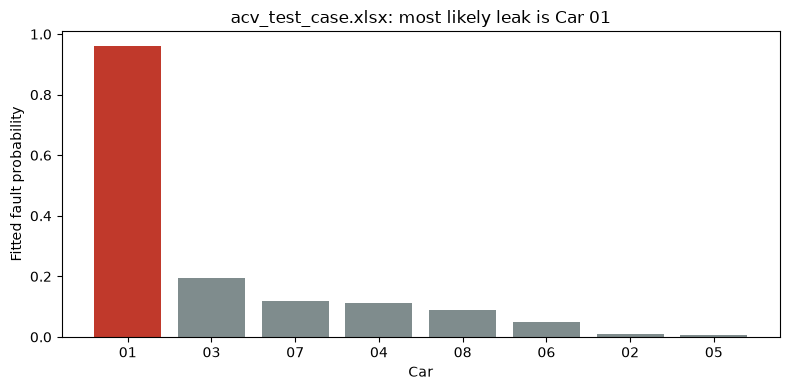

In [15]:
test_ranked = test_scored[test_paths[0].name]["probability"]

colors = ["#c0392b" if car == test_ranked.index[0] else "#7f8c8d" for car in test_ranked.index]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(test_ranked.index, test_ranked.values, color=colors)
ax.set_xlabel("Car")
ax.set_ylabel("Fitted fault probability")
ax.set_title(f"{test_paths[0].name}: most likely leak is Car {test_ranked.index[0]}")
fig.tight_layout()